In [1]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d_v3 as two
import plot_tools as pt
import utils_AWE as awe

import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
import time
import matplotlib.colors as mcolors

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = "/home/r/Robert.Reichert/Robert.Reichert/data/SWOT/SSHA_right.nc"
ds = xr.open_dataset(data_path)

In [3]:
orig = ds["ssha"]
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values)
dx, dy = 250, 250
nx, ny = orig['x'].size, orig['y'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3
print('Domain size:', nx, ny)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

Domain size: 2000 240


In [4]:
s0 = 2 #smallest scale that we wanna resolve
s1 = 0.25 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 4 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 17
print('Decomposition shape will be: ', js, jt, nx, ny)

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

Decomposition shape will be:  19 17 2000 240


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 0 km and the smallest wavelength you analyze is 0 km.
The data domain is at least 60 km and the largest wavelength you analyze is 11 km.


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [6]:
# Denoising
noise_floor = 0.03 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=4*noise_floor,mean_axis=(1,2,3))

Text(0.03, 0.94, 'c')

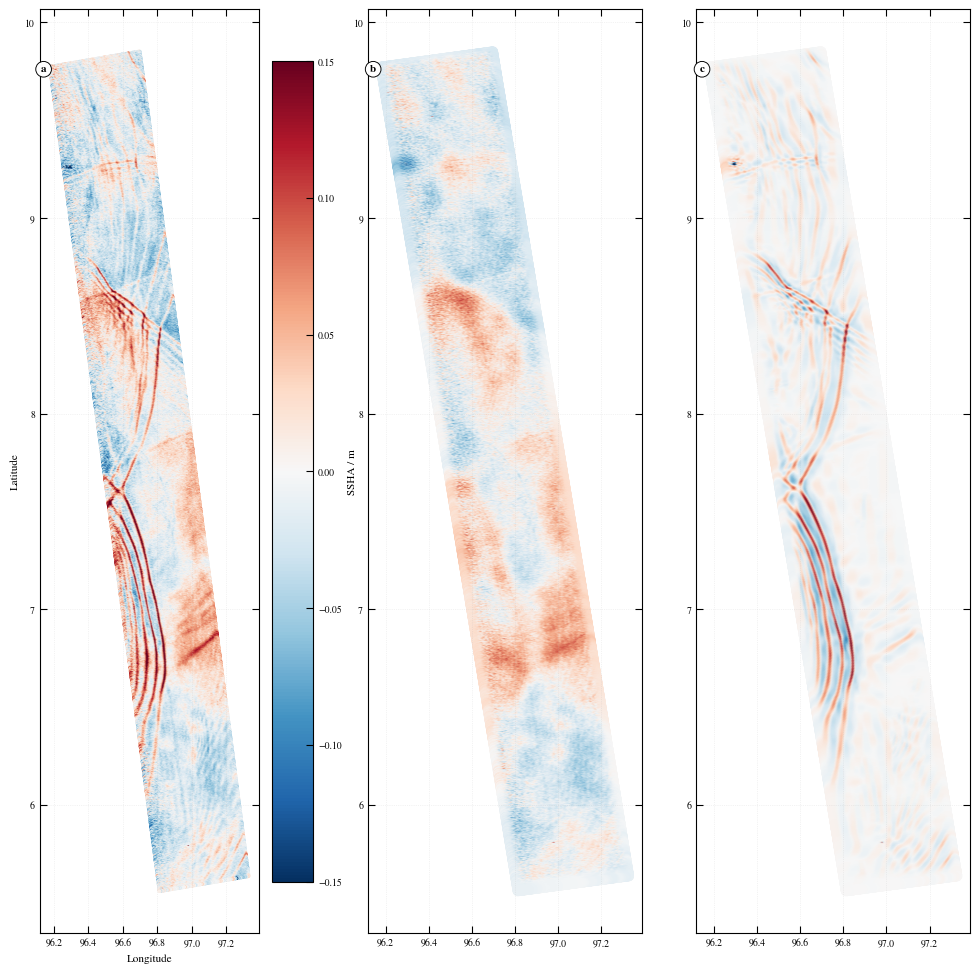

In [7]:
BI_lev = np.linspace(-0.15,0.15,31)
fig = plt.figure(figsize=(12,12))
ax1 = fig.add_subplot(131)
plot_orig = ax1.scatter(ds.lon,ds.lat,c=orig,s=2,cmap='RdBu_r', vmin=-0.15, vmax=0.15)
cbar = fig.colorbar(plot_orig,ticks=[-0.15,-0.1,-0.05,0,0.05,0.1,0.15],label='SSHA / m')

ax2 = fig.add_subplot(132)
plot_dirt = ax2.scatter(ds.lon,ds.lat,c=BI_low+signal-wavy_stuff,cmap='RdBu_r',vmin=-0.15,vmax=0.15)
#plot_dirt = ax2.scatter(ds.lon,ds.lat,c=BI_low+signal-wavy_stuff+np.mean(orig.values),cmap='RdBu_r',vmin=-0.15,vmax=0.15)
#cbar = fig.colorbar(plot_dirt,ticks=[0,5,10,15,20],label='Q-line radiance')

ax3 = fig.add_subplot(133)
plot_wave = ax3.scatter(ds.lon,ds.lat,c=wavy_stuff,cmap='RdBu_r',vmin=-0.15,vmax=0.15)
#cbar = fig.colorbar(plot_wave,ticks=[-5,-2.5,0,2.5,5],label='Q-line radiance')

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

In [8]:
WAS        = np.abs(denoised_cwt['decomposition'])
start_time = time.time()
seg_v1     = two.wavefield_segmentation_2d(WAS,0.01,connectivity=1)
print("--- %s seconds ---" % (time.time() - start_time))
print('Identified', np.max(seg_v1), 'initial wave packets!')

--- 1200.486333847046 seconds ---
Identified 26 initial wave packets!


In [9]:
k     = 2 * np.pi / cwt_result["period"]
theta = cwt_result["theta"]
eps   = np.abs(np.diff(np.log(k)))[0]*np.sqrt(2)
labels, cluster_labels = two.find_clusters_logk_theta(denoised_cwt, seg_v1, eps=eps)
cluster_map            = two.build_cluster_map_with_noise(labels,cluster_labels)
seg_v2                 = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Number of wave packets after Clustering', np.max(seg_v2))

suggested scaling: 0.9377013006487718
Number of wave packets after Clustering 26


In [10]:
seg_v3 = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.98)
print('Final number of wave packets:', np.max(seg_v3))

Final number of wave packets: 4


In [14]:
recon_WP, amp_WP, k_across_WP, k_along_WP = two.recon_allWP_2d(denoised_cwt, seg_v2)

100%|██████████| 480000/480000 [00:15<00:00, 30729.97it/s]


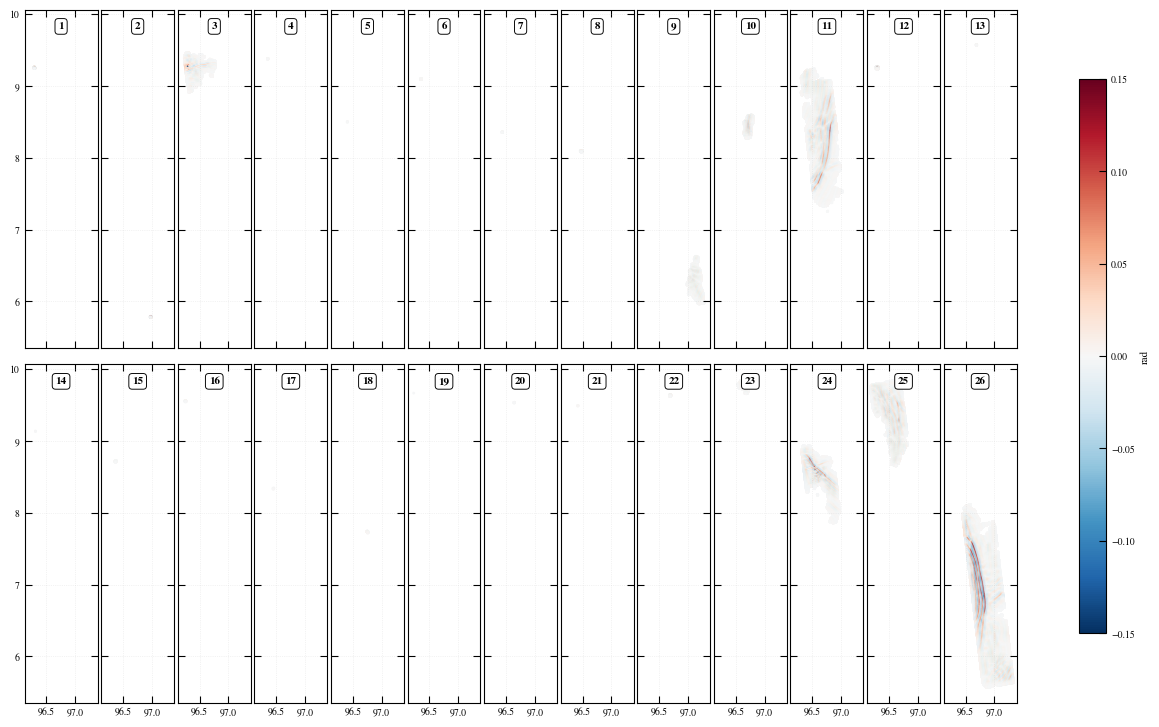

In [16]:
rad_lev = np.linspace(-0.15, 0.15, 31)

lon = ds.lon
lat = ds.lat

lat0 = np.nanmean(lat)

data_aspect = (
    (lon.max() - lon.min()) * np.cos(np.deg2rad(lat0))
    / (lat.max() - lat.min())
)

row, col = pt.define_figgrid(recon_WP.shape[0], data_aspect=float(data_aspect))

gskw = {"hspace": 0.05,"wspace": 0.05,"width_ratios": [1] * col,"height_ratios": [1] * row}

fig, ax = plt.subplots(row, col, figsize=(16, 9), gridspec_kw=gskw, sharex=True, sharey=True, squeeze=False)

for i in range(row):
    for j in range(col):
        idx = i * col + j

        if idx < recon_WP.shape[0]:
            masked = np.ma.masked_inside(recon_WP[idx, :, :], -0.001, 0.001)

            sc = ax[i, j].scatter(lon, lat, c=masked, s=1, cmap="RdBu_r", vmin=-0.15, vmax=0.15)

            ax[i, j].text(0.5, 0.95, str(idx + 1), va="center", ha="center", transform=ax[i, j].transAxes, weight="bold", bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

        else:
            ax[i, j].set_visible(False)

fig.colorbar(sc,ax=ax,orientation="vertical",shrink=0.8,label="rad")

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

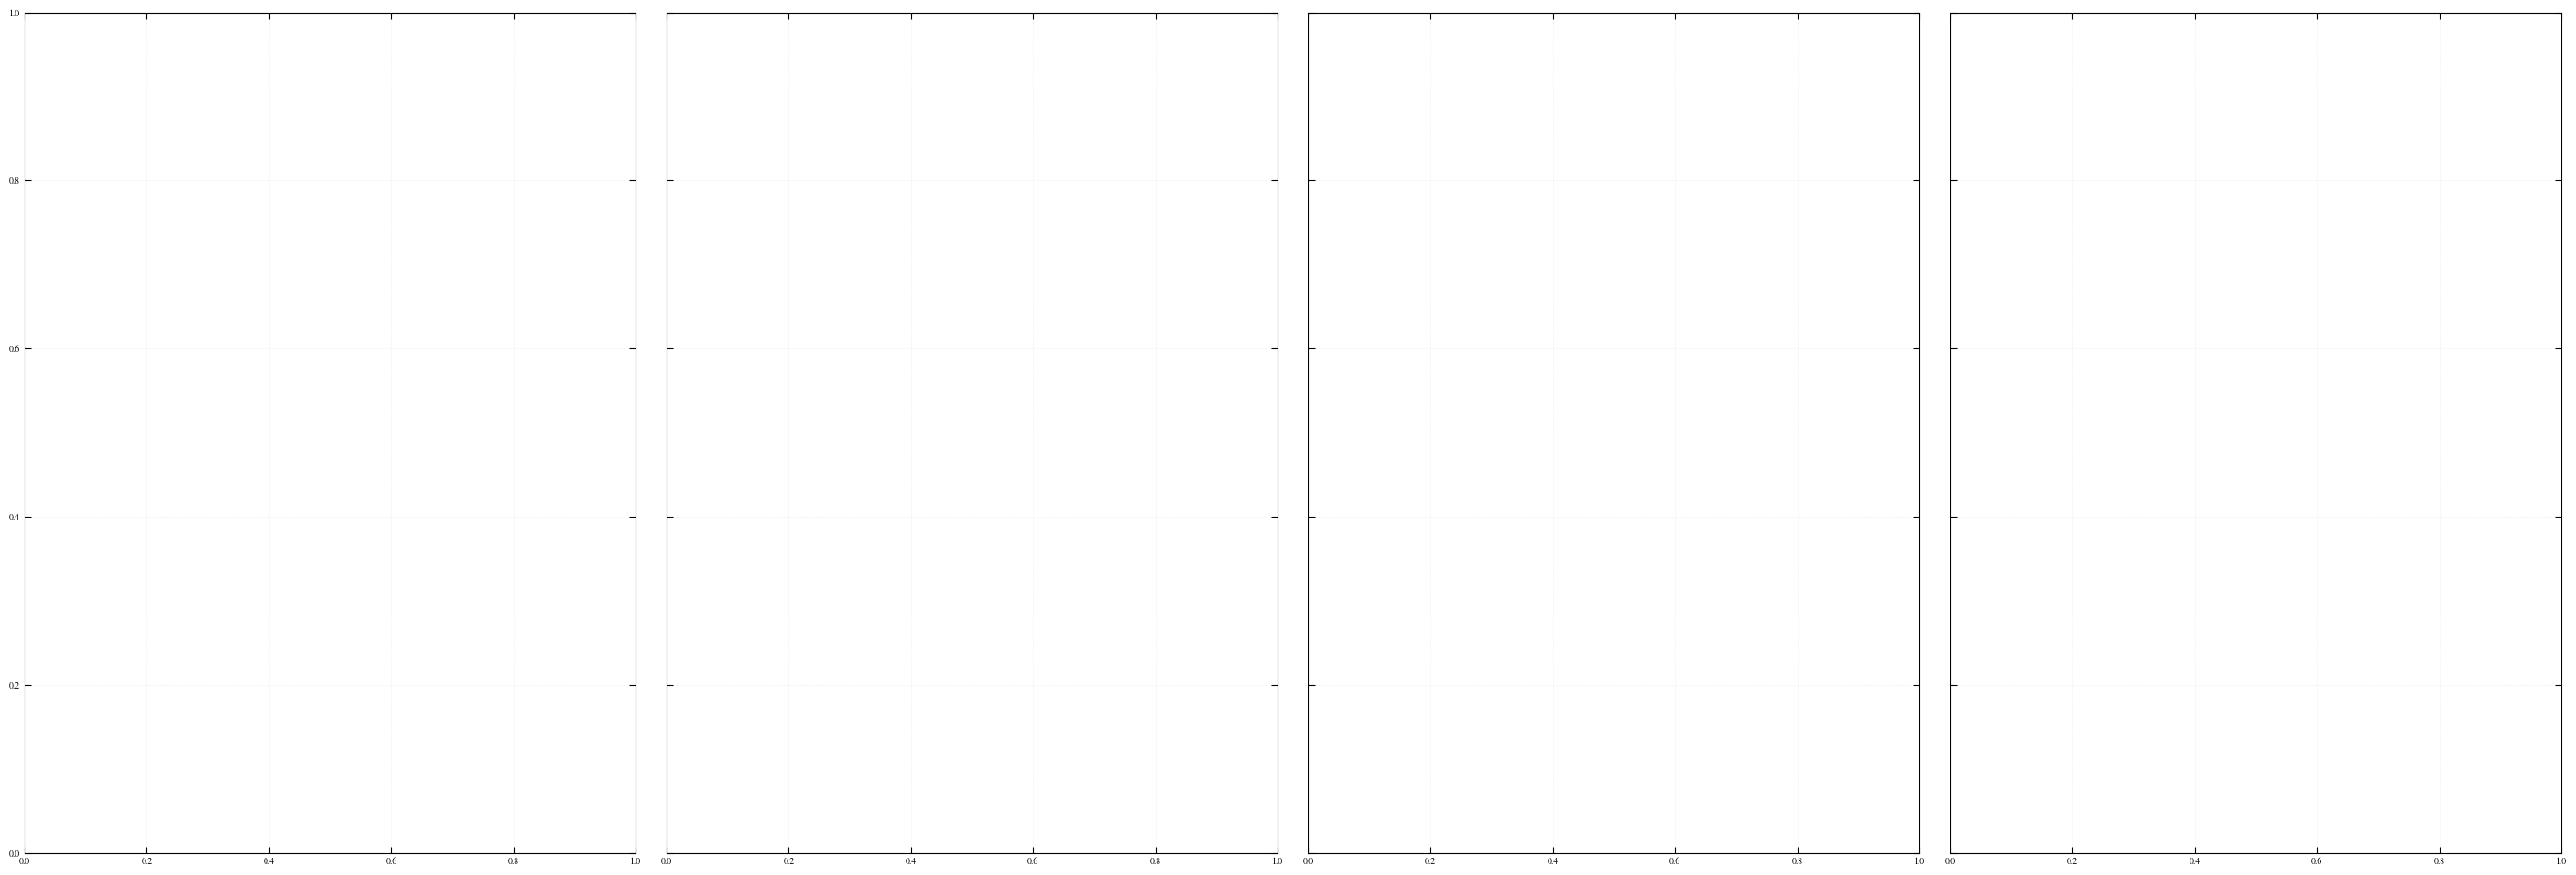

In [17]:
rad_lev=np.linspace(-0.15,0.15,31)

lon = ds.lon
lat = ds.lat
lat0 = np.nanmean(lat)

data_aspect = ((lon.max() - lon.min()) * np.cos(np.deg2rad(lat0))) / (lat.max() - lat.min())

row, col = define_figgrid(recon_WP.shape[0],data_aspect=data_aspect)
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row, col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -0.03, 0.03)  
            norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
            ax[i,j].scatter(lon,lat,c=masked,s=1,cmap="RdBu_r",vmin=rad_lev[0],vmax=rad_lev[-1])
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

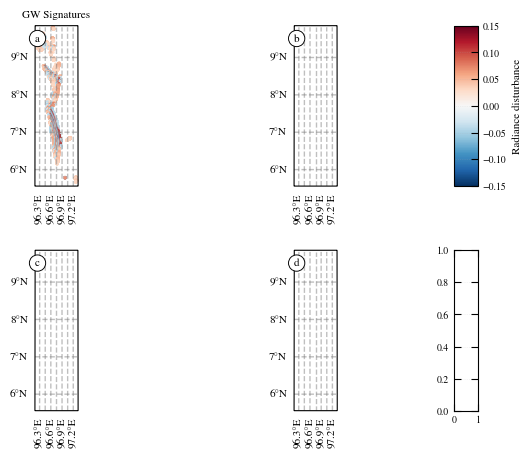

In [15]:
GW_1 = np.sum(recon_WP,axis=0)

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
lon = ds.lon#['Longitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
lat = ds.lat#['Latitude'].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))

lon_min = float(np.nanmin(lon))# + 1
lon_max = float(np.nanmax(lon))# - 1
lat_min = float(np.nanmin(lat))# + 0.5
lat_max = float(np.nanmax(lat))# - 0.5

clon = 0.5 * (lon_min + lon_max)
clat = 0.5 * (lat_min + lat_max)

projStr = ccrs.Stereographic(
    central_longitude=clon,
    central_latitude=clat
)

wave_lev = np.linspace(-0.15,0.15,31)

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(
    2, 3,
    hspace=0.4, wspace=0.1,
    width_ratios=[10, 10, 1],
    height_ratios=[1, 1]
)

# map axes
ax00 = fig.add_subplot(gs[0, 0], projection=projStr)
ax01 = fig.add_subplot(gs[0, 1], projection=projStr)
ax10 = fig.add_subplot(gs[1, 0], projection=projStr)
ax11 = fig.add_subplot(gs[1, 1], projection=projStr)

# colorbar axes (normal axes, no projection)
cax0 = fig.add_subplot(gs[0, 2])
cax1 = fig.add_subplot(gs[1, 2])

map_axes = [ax00, ax01, ax10, ax11]

xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = pt.nice_boundary_path_for_maps(xs, ys)

for a in map_axes:
    a.set_boundary(path, transform=ccrs.PlateCarree())
    a.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    a.coastlines(resolution='110m')

    gl = a.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1,
        color="gray",
        alpha=0.5,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
    gl.right_labels = False

masked = np.ma.masked_inside(wavy_stuff, -0.03, 0.03)
plot_waves = ax00.scatter(lon, lat, c=masked, s=2, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-0.15, vmax=0.15)
cbar = fig.colorbar(plot_waves,cax=cax0,orientation='vertical',pad=0.05,label='Radiance disturbance')#,ticks=[-3, -2, -1, 0, 1, 2, 3])
ax00.set_title('GW Signatures')

"""

masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax00.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax00.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
cbar = fig.colorbar(plot_KTLX,cax=cax1,orientation='vertical',pad=0.05,label='Radar Reflectivity / dBZ',ticks=[30,40,50,60])

masked = np.ma.masked_inside(recon_domi, -0.2, 0.2)  
plot_domi = ax01.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree())
ax01.set_title('Dominant GW')


masked = np.ma.masked_inside(GW_1, -0.2, 0.2)  
plot_GW1 = ax10.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
ax10.set_title('Convective GW I')
masked_KTLX = np.ma.masked_less(ds_KTLX['DBZH_lonlat'].values, 30)
plot_KTLX = ax10.pcolormesh(ds_KTLX.longitude, ds_KTLX.latitude, masked_KTLX, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')


masked = np.ma.masked_inside(GW_2, -0.2, 0.2)  
plot_GW2 = ax11.contourf(lon, lat, masked, levels=wave_lev, cmap='RdBu_r', transform=ccrs.PlateCarree(), extend='both')
ax11.set_title('Convective GW II')
masked_KDDC = np.ma.masked_less(ds_KDDC['DBZH_lonlat'].values, 30)
plot_KDDC = ax11.pcolormesh(ds_KDDC.longitude, ds_KDDC.latitude, masked_KDDC, cmap='plasma', vmin=30, vmax=65, transform=ccrs.PlateCarree(), shading='auto')
"""

label=['a','b','c','d']
for i,a in enumerate(map_axes):
    a.text(0.06,0.92,label[i],va='center', ha='center', bbox=letterbox, transform=a.transAxes)

#plt.savefig('./figures/figure_3_v2.png', dpi=300, bbox_inches="tight",pad_inches=0.03)

<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
/scratch-local/slurm-job-tmp-14962700/ipykernel_638/735613602.py:18: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Orientation / $\circ$')


Text(0.5, 0, 'Orientation / $\\circ$')

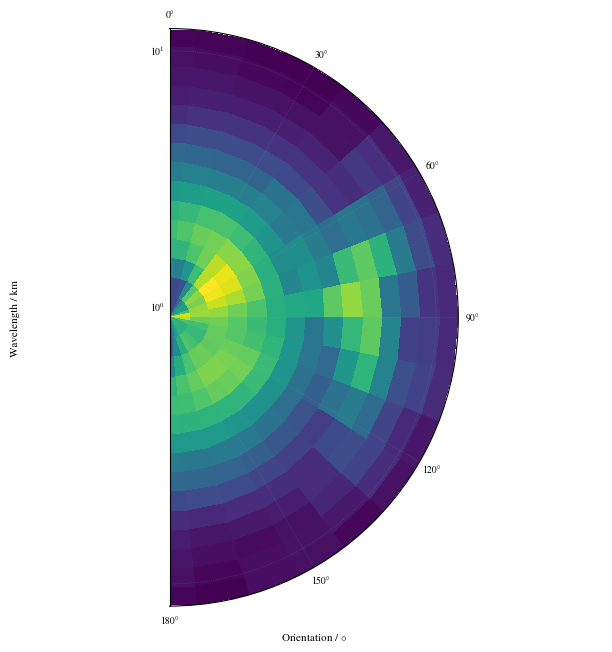

In [8]:
sel_WPS = np.nanmax(WAS,axis=(2,3))
th=denoised_cwt['theta']
th2 = np.append(th,th+np.pi)
pe=denoised_cwt['period']
#spec_lev = pc.cmap_range(sel_WPS, [1,99], diverging=False, fix_zero=True, num_levels=31)
sel_WPS_pad = np.pad(sel_WPS, ((0,0),(0,sel_WPS.shape[1])), mode="wrap")

fig = plt.figure(figsize=(0.5*len(denoised_cwt['theta']),0.5*len(denoised_cwt['scale'])))
ax=fig.add_subplot(projection='polar')

pcm = ax.pcolormesh(th2,pe*1e-3,sel_WPS_pad, shading="auto")#vmin=spec_lev.min(), vmax=spec_lev.max(),)
ax.set_yscale('log')
ax.set_theta_zero_location("N")  # theta=0 at the top
ax.set_theta_direction(-1)
ax.set_xlim([0,np.pi])

ax.set_ylabel('Wavelength / km')
ax.set_xlabel('Orientation / $\circ$')
#ax.set_yticks(ticks=[8,16,32,64,128,256],labels=[8,16,32,64,128,256])

#plt.savefig('./AWE_plots/mean_spectrum_02514.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [9]:
WAS        = np.abs(denoised_cwt['decomposition'])
seg_v1     = two.wavefield_segmentation_2d(WAS,noise_floor,connectivity_order=2)
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels  = np.arange(1,np.max(seg_v1)+1)
cluster_labels = two.find_clusters_in_freq_theta(denoised_cwt, seg_v1, eps=0.1)
cluster_map    = two.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))
seg_v3         = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 112 initial wave packets!
Reduced the number of wave packets to 17
Final number of wave packets: 6
